# implementasi linear SVM (toleransi error --> pakai soft margin)

soft margin membiar outliers/noise ada, tapi dengan penalti (mengontrol pengaruhnya).

## data

In [1]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [2, 2],
    [2, 3],
    [3, 3],
    [6, 6],
    [7, 7],
    [8, 6]
])

y = np.array([-1, -1, -1, 1, 1, 1])

## implementasi

`class linearSVM`: untuk membuat objek model linear SVM. model linear SVM nya memiliki kemampuan untuk
- diinisialisasi (__init__)
- dilatih (fit)
- menebak (predict)

1) `def __init__(self, lr=0.001, lambda_param=0.01, n_iters=1000):` untuk mengatur hyperparameter.
parameternya:
`lr`: learning rate (ukuran langkah yang diambil model saat memperbarui w dan b).
`lambda_param`: regularization strength yg membuat model ini menjadi soft margin, mengontrol seberapa besar model menoleransi error. makin besar nilainya, margin akan dibuat makin lebar (lebih toleran), tapi akurasi pada training set mungkin sedikit menurun.
`n_iters`: jumlah iterasi (epoch), menentukan berapa kali model akan melihat keseluruhan training set untuk belajar dan koreksi kesalahannya.

3) `def fit(self, X, y):` untuk melatih model. model menerima data fitur dan label, lalu iterasi menyesuaikan hyperlane. model akan mencari nilai bobot optimal (w) dan bias (b) berdasarkan aturan gradient descent sampai menemukan posisi garis paling pas.
steps:
1. `n_samples, n_features = X.shape`ambil ukuran data --> untuk membuat bobot (w). misal, 2 fitur -> 2 bobot.
2. inisialisasi garis tanpa arah
3. decision rule yi(w.xi+b)≥1
   true: titik di luar margin --> model tidak mendapat penalti (error = 0) --> bobot dw diupdate sedikit biar margin tetap lebar (`dw = 2 * self.lambda_param * self.w`)
   false: titik salah klasifikasi, masuk margin --> model mendapat penalti --> bobot dw diupdate dengan mempertimbangkan posisi titik tersebut agar hyperplane bergeser (`dw = 2 * self.lambda_param * self.w - y[idx] * x_i`)

3) `def predict(self, X):` untuk memprediksi. fungsi ini memasukkan data baru (X) ke dalam persamaan garis f(x) = w^T x + b. fungsi `np.sign` mengubah hasil perhitungannya menjadi -1 atau 1 (biner).
`np.dot(X, self.w) + self.b` menghitung posisi titik data baru terhadap hyperlane -> hasil + (kanan); - (kiri)
`np.sign()` -> + jadi 1; - jadi -1


### steps
1. mendefinisikan objektif
2. menghitung decision function f(x)=w^Tx+b
3. menghitung loss
4. mengupdate parameter
5. iterasi
6. prediksi

In [2]:
class linearSVM:
    def __init__(self, lr=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = lr
        self.lambda_param = lambda_param
        self.n_iters = n_iters

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0
        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                condition = y[idx] * (np.dot(x_i, self.w) + self.b) >= 1
                if condition:
                    dw = 2 * self.lambda_param * self.w
                    db = 0
                else:
                    dw = 2 * self.lambda_param * self.w - y[idx] * x_i
                    db = -y[idx]

                self.w -= self.lr * dw
                self.b -= self.lr * db

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

## train

In [3]:
model = linearSVM()
model.fit(X, y)

print("w:", model.w)
print("b:", model.b)

w: [ 0.64268437 -0.1983292 ]
b: -1.6789999999999259


## cek margin

In [4]:
margin = 2 / np.linalg.norm(model.w)
print("Margin:", margin)

Margin: 2.9735785568008755


## cek jarak tiap titik ke hyperlane 

In [5]:
def distance_to_hyperplane(X, w, b):
    return np.abs(np.dot(X, w) + b) / np.linalg.norm(w)

distances = distance_to_hyperplane(X, model.w, model.b)
print(distances)

[1.17499421 1.46986794 0.51433171 1.46765577 2.12831826 3.37872822]


## cari support vectors

In [6]:
decision_values = y * (np.dot(X, model.w) + model.b)

support_vectors = X[np.isclose(decision_values, 1, atol=0.1)]
print("Support vectors:\n", support_vectors)

Support vectors:
 [[2 3]
 [6 6]]


## visualisasi

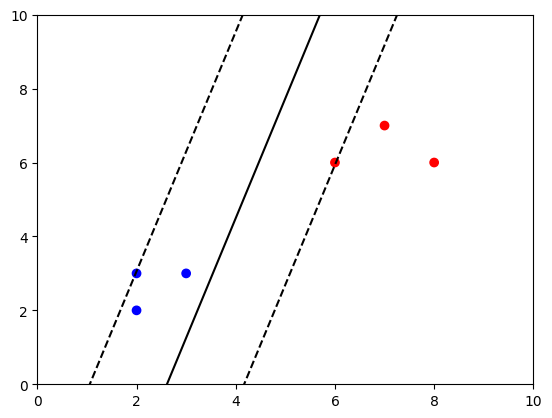

In [7]:
def plot_svm(X, y, w, b):
    plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr')

    def hyperplane(x, w, b, offset):
        return (-w[0]*x - b + offset) / w[1]

    x0 = np.linspace(0, 10, 100)

    # decision boundary
    plt.plot(x0, hyperplane(x0, w, b, 0), 'k')

    # margins
    plt.plot(x0, hyperplane(x0, w, b, 1), 'k--')
    plt.plot(x0, hyperplane(x0, w, b, -1), 'k--')

    plt.xlim(0, 10)
    plt.ylim(0, 10)
    plt.show()

plot_svm(X, y, model.w, model.b)

# Pake sklearn

w: [[0.33333333 0.33333333]]
b: [-3.]
[[3. 3.]
 [6. 6.]]
[-1 -1 -1  1  1  1]


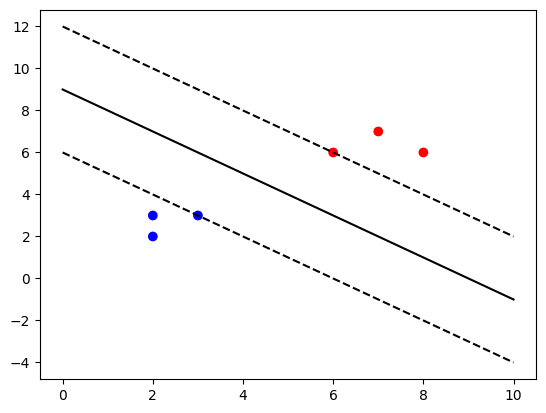

In [10]:
from sklearn import svm

## train
model = svm.SVC(kernel='linear', C=1.0)
model.fit(X, y)

print("w:", model.coef_)
print("b:", model.intercept_)
print(model.support_vectors_)

## prediksi
pred = model.predict(X)
print(pred)

## visualisasi
def plot_sklearn_svm(X, y, model):
    plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr')

    w = model.coef_[0]
    b = model.intercept_[0]

    x0 = np.linspace(0, 10, 100)
    decision = (-w[0]*x0 - b) / w[1]
    margin1 = (-w[0]*x0 - b + 1) / w[1]
    margin2 = (-w[0]*x0 - b - 1) / w[1]

    plt.plot(x0, decision, 'k')
    plt.plot(x0, margin1, 'k--')
    plt.plot(x0, margin2, 'k--')

    plt.show()

plot_sklearn_svm(X, y, model)